In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, classification_report

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [ ]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df['Unnamed: 2'].value_counts()

,count
Unnamed: 2,
"bt not his girlfrnd... G o o d n i g h t . . .@""",3
"this wont even start........ Datz confidence..""",2
PO Box 5249,2
"don't miss ur best life for anything... Gud nyt...""",2
GN,2
"but dont try to prove it..\"" .Gud noon....""",2
"HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE JEN XXX\""""",1
".;-):-D""",1
"wanted to say hi. HI!!!\"" Stop? Send STOP to 62468""",1


In [ ]:
df['Unnamed: 3'].value_counts()


,count
Unnamed: 3,
"MK17 92H. 450Ppw 16""",2
GE,2
why to miss them,1
"U NO THECD ISV.IMPORTANT TOME 4 2MORO\""""",1
i wil tolerat.bcs ur my someone..... But,1
"ILLSPEAK 2 U2MORO WEN IM NOT ASLEEP...\""""",1
"whoever is the KING\""!... Gud nyt""",1
TX 4 FONIN HON,1
"\""OH No! COMPETITION\"". Who knew",1


In [ ]:
df['Unnamed: 4'].value_counts()


,count
Unnamed: 4,
"GNT:-)""",2
"just Keep-in-touch\"" gdeve..""",1
"Never comfort me with a lie\"" gud ni8 and sweet dreams""",1
"CALL 2MWEN IM BK FRMCLOUD 9! J X\""""",1
"one day these two will become FREINDS FOREVER!""",1


In [ ]:
# remove null collumns
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [ ]:
df.isna().sum()

,0
v1,0
v2,0


In [ ]:
# rename v1, v2
df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)

In [ ]:
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## preprocessing

### lower

In [ ]:
df['text'] = df['text'].apply(lambda x: x.lower())

### tokenization

In [ ]:
nltk.download('punkt_tab')
df['text'] = df['text'].apply(nltk.word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
df.head()

,label,text
0,ham,"[go, until, jurong, point, ,, crazy, .., avail..."
1,ham,"[ok, lar, ..., joking, wif, u, oni, ...]"
2,spam,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,ham,"[u, dun, say, so, early, hor, ..., u, c, alrea..."
4,ham,"[nah, i, do, n't, think, he, goes, to, usf, ,,..."


In [ ]:
import string
def remove_special_chars_and_numbers(text_list):
    # Remove punctuation
    no_punct = [char for char in text_list if char not in string.punctuation]
    # Remove numbers
    no_numbers = [word for word in no_punct if not word.isdigit()]
    return no_numbers

df['text'] = df['text'].apply(remove_special_chars_and_numbers)

### stop words

In [ ]:
stop_words = set(stopwords.words('english'))
def remove_stopwords(text_list):
    return [word for word in text_list if word not in stop_words]

df['text'] = df['text'].apply(remove_stopwords)

### stemming

In [ ]:
ps = PorterStemmer()
def stem_text(text_list):
    return [ps.stem(word) for word in text_list]

df['text'] = df['text'].apply(stem_text)

### lemmatization

In [ ]:
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
def lemmatize_text(text_list):
    return [lemmatizer.lemmatize(word) for word in text_list]

df['text'] = df['text'].apply(lemmatize_text)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df

,label,text
0,ham,"[go, jurong, point, crazi, .., avail, bugi, n,..."
1,ham,"[ok, lar, ..., joke, wif, u, oni, ...]"
2,spam,"[free, entri, wkli, comp, win, fa, cup, final,..."
3,ham,"[u, dun, say, earli, hor, ..., u, c, alreadi, ..."
4,ham,"[nah, n't, think, goe, usf, live, around, though]"
...,...,...
5567,spam,"[2nd, time, tri, contact, u., u, å£750, pound,..."
5568,ham,"[ì_, b, go, esplanad, fr, home]"
5569,ham,"[piti, mood, ..., suggest]"
5570,ham,"[guy, bitch, act, like, 'd, interest, buy, som..."


### TF-IDF

In [ ]:
# Convert list of tokens back to string for TF-IDF Vectorizer
df['text_processed'] = df['text'].apply(lambda x: ' '.join(x))

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df['text_processed'])

print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (5572, 5000)


## split

In [ ]:
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## Helper Function

In [ ]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix
def train_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix is:")
    # print(matrix)


    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted No", "Predicted Yes"],
                yticklabels=["Actual No", "Actual Yes"])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    print("\n\nScore Table is: ")
    score_df = pd.DataFrame([[accuracy, precision, recall, f1]],
                            columns=["accuracy", "precision", "recall", "f1"])

    return score_df

## model

### naive bayes

Confusion Matrix is:


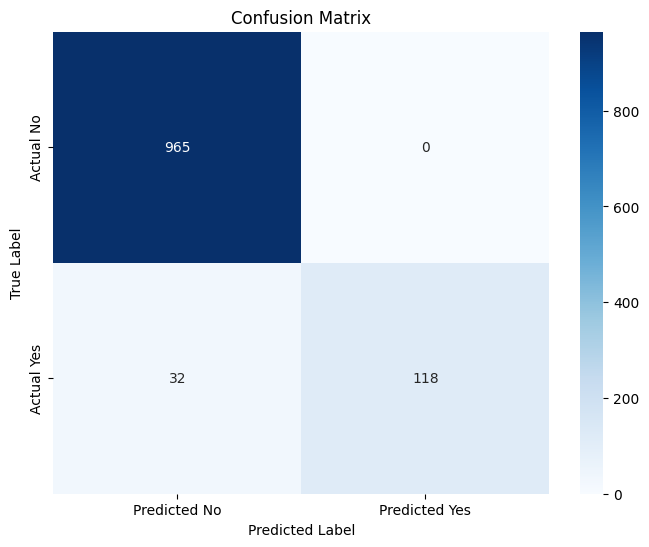



Score Table is: 


,accuracy,precision,recall,f1
Naive bayes,0.9713,0.972222,0.9713,0.969821


In [ ]:
model = MultinomialNB()
result=train_model(model,X_train, y_train, X_test, y_test)
result.index=["Naive bayes"]
result

### LogisticRegression

Confusion Matrix is:


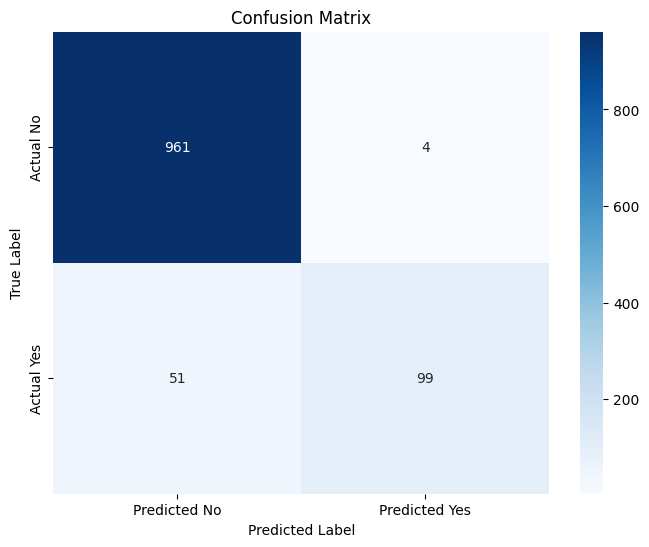



Score Table is: 


,accuracy,precision,recall,f1
Naive bayes,0.971300,0.972222,0.971300,0.969821
Logistic Regression,0.950673,0.951160,0.950673,0.946677


In [ ]:
model = LogisticRegression()
lr_result = train_model(model, X_train, y_train, X_test, y_test)
lr_result.index = ["Logistic Regression"]
result = pd.concat([result, lr_result])
display(result)